In [3]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
import sys
import os
sys.path.append(os.path.abspath("code"))
#My jupyter notebook has some problems in finding the right folder, that's why I put this line below
os.chdir(r'C:\Users\vitto\OneDrive\Desktop\MyProject')
from pywt import scale2frequency
from pywt import cwt
from scipy.stats import zscore
import lfp_functions as lf

In [4]:
# Import the data from data/sleep_lfp.pickle
with open('data/sleep_lfp.pickle', 'rb') as handle:
    lfp_data = pickle.load(handle)

sleep_lfp = lfp_data['lfp']
sampling_rate = lfp_data['sampling_rate']
print(f'Loaded {len(sleep_lfp)/sampling_rate} seconds of LFP, sampled at {sampling_rate} Hz')

Loaded 1816.576 seconds of LFP, sampled at 1000.0 Hz


In [5]:
# Compute the instantaneous power in the theta (6-10 Hz) and delta (2-4 Hz) bands for the whole signal
theta_power = lf.power(sleep_lfp, low_f=6, high_f=10, sampling_rate=sampling_rate)
delta_power = lf.power(sleep_lfp, low_f=2, high_f=4, sampling_rate=sampling_rate)

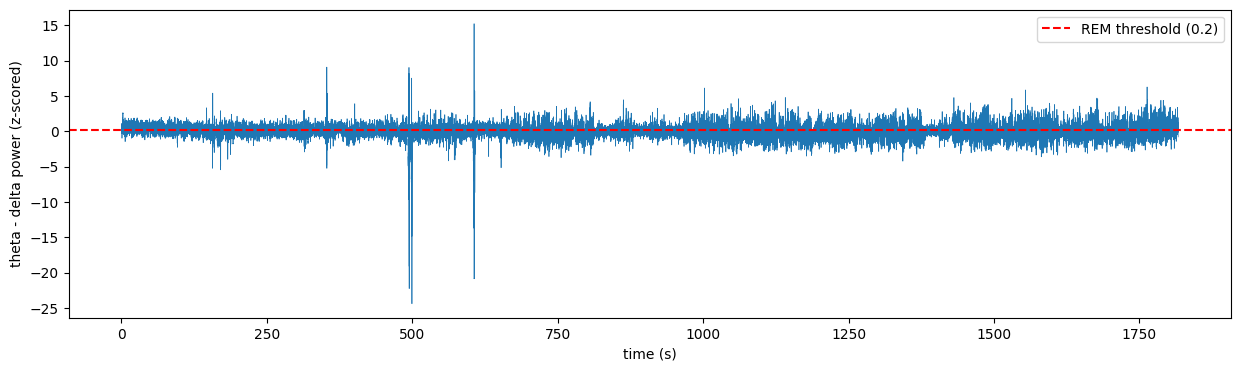

In [6]:
# Z-score the two power signals and compute the difference (theta - delta)
theta_power = zscore(theta_power)
delta_power = zscore(delta_power)

power_diff = theta_power - delta_power

time = np.arange(len(power_diff)) / sampling_rate

plt.figure(figsize=(15, 4))
plt.plot(time, power_diff, lw=0.5)
plt.axhline(y=0.2, linestyle='--', c='r', label='REM threshold (0.2)')
plt.xlabel('time (s)')
plt.ylabel('theta - delta power (z-scored)')
plt.legend()

In [7]:
# Compute the REM (power difference > 0.2) and nREM (power difference <= 0.2) periods
rem_mask  = power_diff > 0.2
nrem_mask = power_diff <= 0.2

print(f'REM  sleep: {rem_mask.sum()  / sampling_rate:.1f} s  ({100*rem_mask.mean():.1f}%)')
print(f'nREM sleep: {nrem_mask.sum() / sampling_rate:.1f} s  ({100*nrem_mask.mean():.1f}%)')

REM  sleep: 708.2 s  (39.0%)
nREM sleep: 1108.4 s  (61.0%)


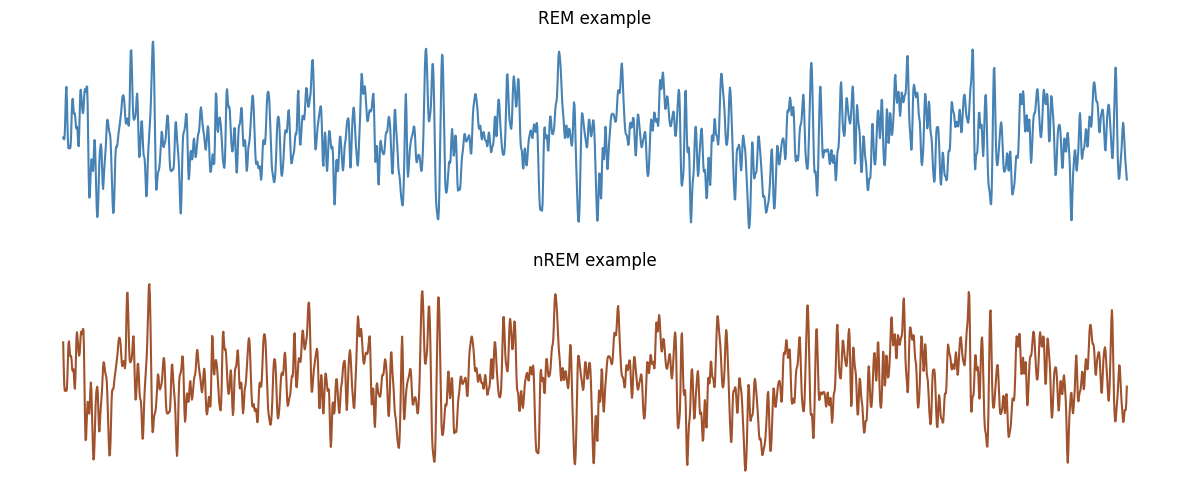

In [8]:
# Plot examples of REM vs nREM LFP (wideband filtered 1-200 Hz)
wideband_lfp = lf.bandpass_filter(sleep_lfp, low_f=1, high_f=200, sampling_rate=sampling_rate)

# find a clean stretch of REM and nREM (at least 2 s long)
window = int(2 * sampling_rate)

rem_onsets  = np.where(np.diff(rem_mask.astype(int))  == 1)[0]
nrem_onsets = np.where(np.diff(nrem_mask.astype(int)) == 1)[0]

rem_start  = rem_onsets[0]
nrem_start = nrem_onsets[0]

plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1)
plt.plot(wideband_lfp[rem_start : rem_start + window], c='steelblue')
plt.title('REM example')
plt.ylabel('voltage (mV)')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.plot(wideband_lfp[nrem_start : nrem_start + window], c='sienna')
plt.title('nREM example')
plt.ylabel('voltage (mV)')
plt.axis('off')

plt.tight_layout()

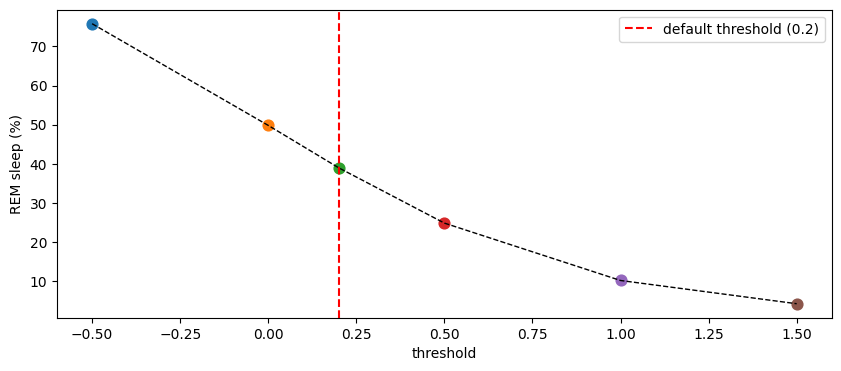

In [9]:
# Explore how changing the threshold affects the amount of REM sleep detected
thresholds = [-0.5, 0, 0.2, 0.5, 1.0, 1.5]

plt.figure(figsize=(10, 4))
for th in thresholds:
    rem_fraction = (power_diff > th).mean() * 100
    plt.scatter(th, rem_fraction, s=60)
    plt.plot(th, rem_fraction, 'o')

plt.plot(thresholds, [(power_diff > th).mean() * 100 for th in thresholds], '--k', lw=1)
plt.axvline(x=0.2, linestyle='--', c='r', label='default threshold (0.2)')
plt.xlabel('threshold')
plt.ylabel('REM sleep (%)')
plt.legend()